In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sid321axn/beijing-multisite-airquality-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\marte\.cache\kagglehub\datasets\sid321axn\beijing-multisite-airquality-data-set\versions\1


In [63]:
import os
import glob
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [62]:
tf.random.set_seed(4) # Just a seed for reproducability

In [3]:
output_file = os.path.join(path, "beijing_all_stations.csv")

# Check if the file exists at that FULL path
if not os.path.exists(output_file):
    # Get all CSV files in the folder
    csv_files = glob.glob(os.path.join(path, "*.csv"))

    # Read each CSV and store in a list
    dfs = []
    for file in csv_files:
        df = pd.read_csv(file)
        dfs.append(df)

    # Concatenate all dataframes
    df = pd.concat(dfs, ignore_index=True)

    # Remove 'No' column if exists
    if 'No' in df.columns:
        df = df.drop(columns=['No', "PM10"])

    # Save to a single CSV
    output_file = os.path.join(path, "beijing_all_stations.csv")
    df.to_csv(output_file, index=False, quoting=csv.QUOTE_ALL)
    print(f"Combined CSV saved to: {output_file}")
    print(f"Shape of combined dataset: {df.shape}")

else:
    df = pd.read_csv(path + "/beijing_all_stations.csv")
    # This will now print correctly because we checked the full path
    print(f"File already exists at '{output_file}'. Skipping concatenation.")

File already exists at 'C:\Users\marte\.cache\kagglehub\datasets\sid321axn\beijing-multisite-airquality-data-set\versions\1\beijing_all_stations.csv'. Skipping concatenation.


In [5]:
df.columns

Index(['year', 'month', 'day', 'hour', 'PM2.5', 'SO2', 'NO2', 'CO', 'O3',
       'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [26]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Sort by station and time
df = df.sort_values(['station', 'datetime'])
df = df.drop(columns=['year', 'month', 'day', 'hour'])
df.head()

,PM2.5,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [27]:
cols = ['PM2.5','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']

df_clean = df.sort_values(['station', 'datetime'])

df_clean[cols] = (df_clean.groupby('station')[cols].transform(lambda g: g.interpolate()))

# handle edge NaNs (when they are at the start or the end)
df_clean[cols] = df_clean[cols].ffill().bfill()

In [28]:
# Best guess for wind direction would be that the missing is still the same as the last hour (forward fill)
df_clean['wd'] = (df_clean.sort_values(['station', 'datetime']).groupby('station')['wd'].ffill())

df_clean['wd'] = df_clean.groupby('station')['wd'].bfill() # Simply if we have missing values at the start, remaining NaN's

In [30]:
# map directions to degrees
wd_map = {'N':0, 'NNE':22.5, 'NE':45, 'ENE':67.5, 'E':90, 'ESE':112.5, 'SE':135, 'SSE':157.5,
    'S':180, 'SSW':202.5, 'SW':225, 'WSW':247.5, 'W':270, 'WNW':292.5, 'NW':315, 'NNW':337.5
}

df_clean['wd_deg'] = df_clean['wd'].map(wd_map)
df_clean['wd_sin'] = np.sin(np.deg2rad(df_clean['wd_deg']))
df_clean['wd_cos'] = np.cos(np.deg2rad(df_clean['wd_deg']))
df_clean = df_clean.drop(columns=['wd','wd_deg'])

In [31]:
df_clean.head()

,PM2.5,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,station,datetime,wd_sin,wd_cos
0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,Aotizhongxin,2013-03-01 00:00:00,-0.382683,0.923880
1,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,Aotizhongxin,2013-03-01 01:00:00,0.000000,1.000000
2,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,Aotizhongxin,2013-03-01 02:00:00,-0.382683,0.923880
3,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,Aotizhongxin,2013-03-01 03:00:00,-0.707107,0.707107
4,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,Aotizhongxin,2013-03-01 04:00:00,0.000000,1.000000


In [32]:
# extract hour of day (0–23) and day of year (1–365)
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day_of_year'] = df_clean['datetime'].dt.dayofyear

# daily cycle
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)

# yearly/seasonal cycle
df_clean['doy_sin'] = np.sin(2 * np.pi * df_clean['day_of_year'] / 365)
df_clean['doy_cos'] = np.cos(2 * np.pi * df_clean['day_of_year'] / 365)

# drop temporary numeric columns
df_clean = df_clean.drop(columns=['hour','day_of_year'])

<Axes: >

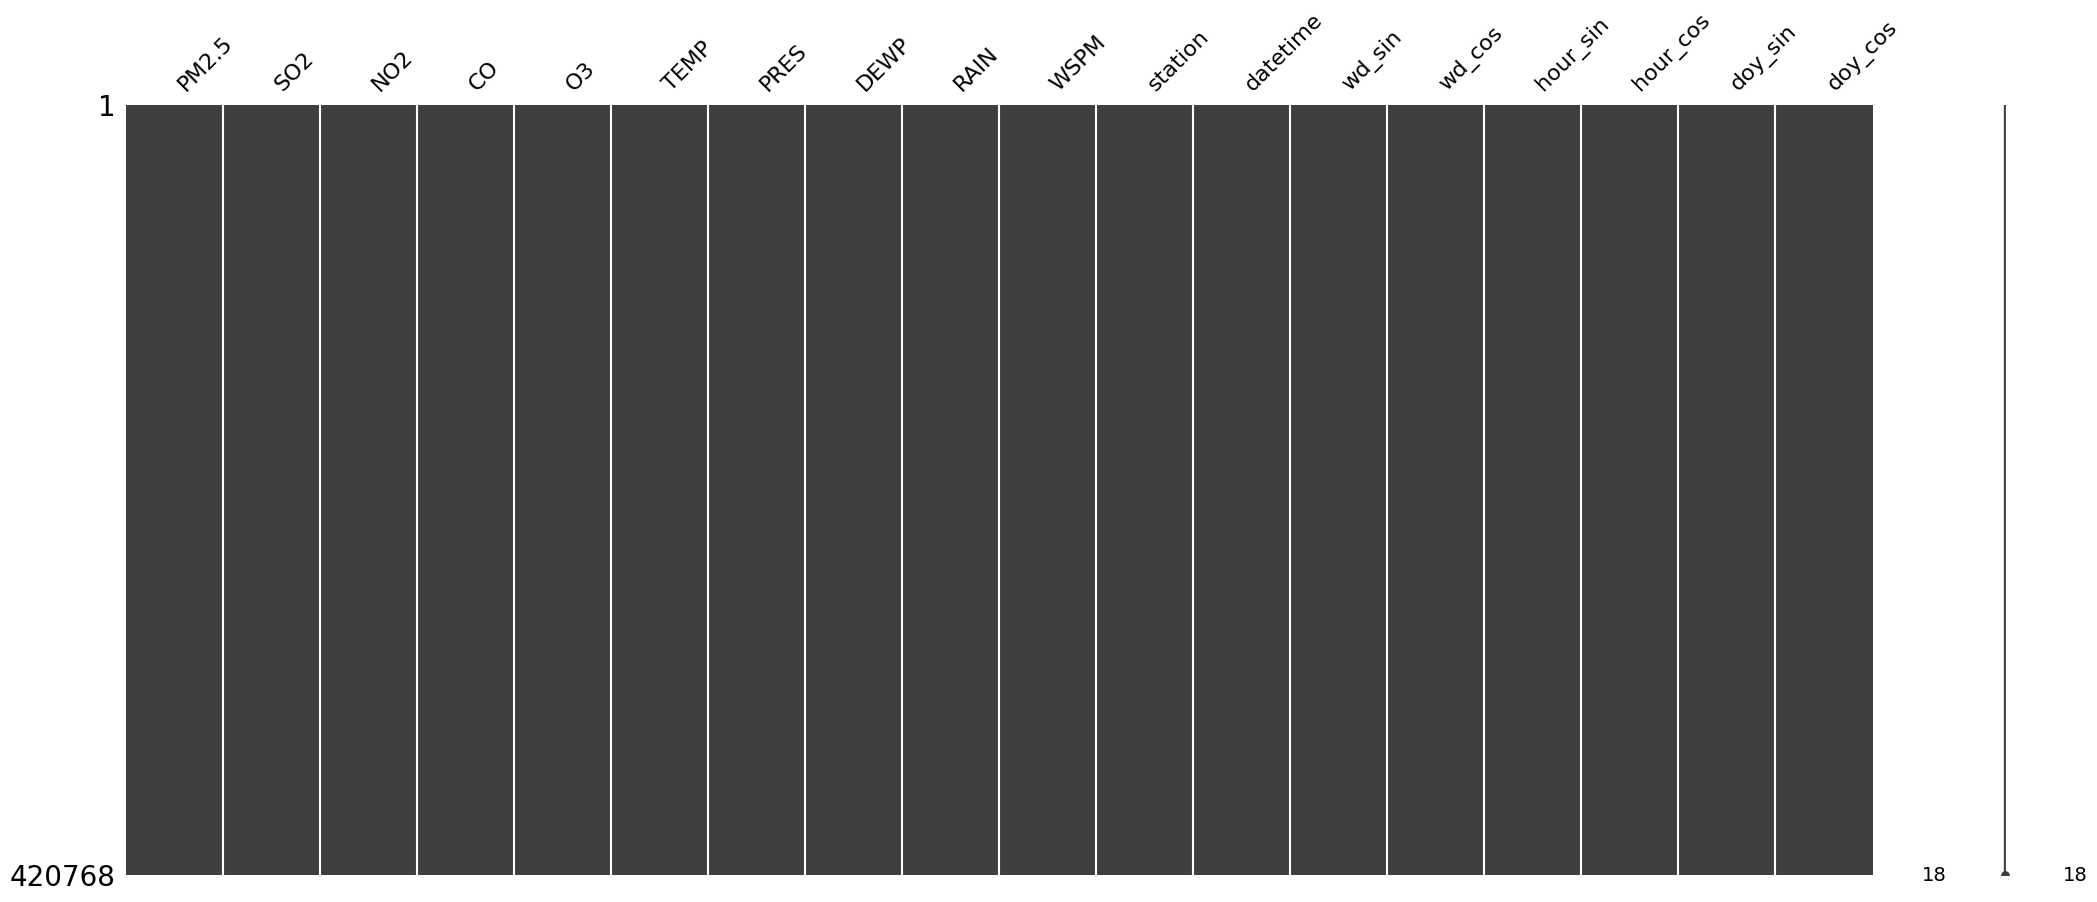

In [33]:
msno.matrix(df_clean)

In [70]:
df_clean.head()

,PM2.5,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,station,datetime,wd_sin,wd_cos,hour_sin,hour_cos,doy_sin,doy_cos
0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,Aotizhongxin,2013-03-01 00:00:00,-0.382683,0.923880,0.000000,1.000000,0.858764,0.512371
1,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,Aotizhongxin,2013-03-01 01:00:00,0.000000,1.000000,0.258819,0.965926,0.858764,0.512371
2,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,Aotizhongxin,2013-03-01 02:00:00,-0.382683,0.923880,0.500000,0.866025,0.858764,0.512371
3,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,Aotizhongxin,2013-03-01 03:00:00,-0.707107,0.707107,0.707107,0.707107,0.858764,0.512371
4,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,Aotizhongxin,2013-03-01 04:00:00,0.000000,1.000000,0.866025,0.500000,0.858764,0.512371


In [71]:
df_clean.columns
df_clean.dtypes

PM2.5              float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
WSPM               float64
station             object
datetime    datetime64[ns]
wd_sin             float64
wd_cos             float64
hour_sin           float64
hour_cos           float64
doy_sin            float64
doy_cos            float64
dtype: object

In [72]:
# Training on one station
df_model = df_clean[df_clean['station'] == 'Aotizhongxin'].copy()

# Drop non-numerical columns we don't need anymore
df_model = df_model.drop(columns=['station', 'datetime'])

## We will convert integers to float32 since that is better suited for neural networks

In [68]:
df_model = df_model.astype('float32')
df_model.dtypes

PM2.5       float32
SO2         float32
NO2         float32
CO          float32
O3          float32
TEMP        float32
PRES        float32
DEWP        float32
RAIN        float32
WSPM        float32
wd_sin      float32
wd_cos      float32
hour_sin    float32
hour_cos    float32
doy_sin     float32
doy_cos     float32
dtype: object

In [90]:
data_values = df_model.values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_values)

target_col_index = 0

In [91]:
# This is just needed because we need 3D data
# Also the target variable is ready for future predictions
def create_lstm_sequences(data, seq_length, target_idx):
    X = []
    y = []
    
    # Iterate through the data
    for i in range(len(data) - seq_length):
        # Gather the past 24 hours of ALL features
        # Shape: (24, 18) -> (Hours, Features)
        X.append(data[i:i+seq_length])
        
        # Gather the target: PM2.5 at the NEXT hour (i + seq_length)
        y.append(data[i+seq_length, target_idx])
        
    return np.array(X), np.array(y)

# Create the 3D Arrays
SEQ_LENGTH = 24
X_lstm, y_lstm = create_lstm_sequences(scaled_data, seq_length=SEQ_LENGTH, target_idx=0)

print(f"Input Shape (X): {X_lstm.shape}")

Input Shape (X): (35040, 24, 16)


# Train/Test Split

In [98]:
split_idx = int(len(X_lstm) * 0.8)
X_train, X_test = X_lstm[:split_idx], X_lstm[split_idx:]
y_train, y_test = y_lstm[:split_idx], y_lstm[split_idx:]

# Build the model

In [99]:
model = Sequential([
    # Input shape is (24, 18) -> (Time Steps, Features)
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Linear output for regression
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

c:\Users\marte\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Train

In [100]:
from tensoflow.

early_stopping = 

history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.0027 - val_loss: 0.0010
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 0.0012 - val_loss: 7.0243e-04
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - loss: 9.2343e-04 - val_loss: 5.7865e-04
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 7.6045e-04 - val_loss: 4.6329e-04
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 6.7065e-04 - val_loss: 4.1849e-04
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - loss: 6.1504e-04 - val_loss: 4.0542e-04
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - loss: 5.8454e-04 - val_loss: 3.9891e-04
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - loss: 5.7042e-04 - val_loss: 3.8996e-04
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 5.5812e-04 - val_loss: 4.0144e-04
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 5.6192e-04 - val_loss: 3.9500e-04
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/s

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Make Predictions (Output is between 0 and 1)
y_pred_scaled = model.predict(X_test)

# 2. Create a dummy array with the same shape as original data (18 columns)
# We fill it with zeros, then place our predictions in the PM2.5 column (index 0)
dummy_array = np.zeros((len(y_pred_scaled), 16)) # 18 = number of features you scaled originally
dummy_array[:, 0] = y_pred_scaled.flatten() # Fill 1st column with predictions

# 3. Inverse Transform
# We get back 18 columns, but we only care about the first one
y_pred_real = scaler.inverse_transform(dummy_array)[:, 0]

# 4. Do the same for y_test (Actual values) to compare apples-to-apples
dummy_y_test = np.zeros((len(y_test), 16))
dummy_y_test[:, 0] = y_test
y_test_real = scaler.inverse_transform(dummy_y_test)[:, 0]

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r_squared = r2_score(y_test_real, y_pred_real)

print(f"Real RMSE: {rmse}")
print(f"R squared: {r_squared}")
print(f"Mean absolute error: {mae}")

219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Real RMSE: 17.776596254256976
R squared: 0.9548009782232176
Mean absolute error: 9.93787500123797
